# SIPTA: Integración Territorial Multidominio -- Tablón Maestro de Bogotá D.C.

**Fase PDCO**: DEVELOPMENT -> CONTROL | **Sprint**: 5  
**Estándares**: Clean Code, PEP 8, DAMA-BOK (Data Integration & Quality), SWEBOK Cap. 2 y 5, IEEE 830 (RF-003, RF-005, RF-007, RF-009, RF-018, RF-019)  
**Sistema**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (SIPTA)

---

## 🎯 Propósito y Alcance del Cuaderno
Este cuaderno constituye el **nodo central de la fase de Integración de Datos (03_integration)**. Su objetivo exclusivo es:
1. **Fuente Única de Población DANE/SDP (2018-2035)**: Integrar las proyecciones oficiales distritales (Total Bogotá 2025: **8.101.412 habitantes**) para todas las 20 localidades canónicas.
2. **Microdatos PUA SDIS 2024 (1.048.575 registros)**: Incorporar atenciones y beneficiarios del Ingreso Mínimo Garantizado (IMG: 666.7k atenciones), comedores comunitarios (43.6k beneficiarios), comisarías y atención a habitante de calle.
3. **Homologación Territorial Canónica**: Unificar los 12 dominios sectoriales bajo los códigos DIVIPOLA oficiales.
4. **Feature Engineering Multidominio**: Derivar densidades espaciales (hab/km²) y tasas per cápita estandarizadas por 1.000, 10.000 y 100.000 habitantes.
5. **Persistencia Contractual**: Exportar el Tablón Maestro Territorial consolidado a `data/processed/master_localidades.csv` (111 columnas x 20 localidades).


## 0. Configuración del Entorno y Carga de Módulos Modulares `src/`

Se configuran las rutas absolutas y se importan los módulos del paquete `src`:
- `src.integration.integrate_data`: Funciones de unión territorial y ensamblaje maestro.
- `src.cleaning.clean_data`: Homologación canónica de nombres y códigos DIVIPOLA.
- `src.features.feature_engineering`: Derivación de densidades y ratios per cápita.
- `src.evaluation.evaluate_results`: Diagnóstico de calidad, completitud y detección de outliers.


In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de rutas relativas a la raiz del repositorio
ROOT = Path.cwd().resolve()
if ROOT.name in ["03_integration", "notebooks"]:
    ROOT = ROOT.parents[1] if ROOT.name == "03_integration" else ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Importacion modular de componentes SIPTA
from src.integration.integrate_data import (
    get_canonical_localities_base,
    merge_by_locality,
    load_demografia_localidades,
    load_vulnerabilidad_social_sdis,
    load_movilidad_infraestructura_coverage,
    build_master_table,
    save_master_table,
)
from src.cleaning.clean_data import MAPA_HOMOLOGACION_LOCALIDADES, standardize_column_names
from src.features.feature_engineering import add_density, add_ratio, save_feature_table
from src.evaluation.evaluate_results import quality_report, detect_outliers, save_quality_report

print(f"[OK] Entorno configurado correctamente. Directorio raiz: {ROOT}")


[OK] Entorno configurado correctamente. Directorio raíz: C:\Users\ADAN\DataJam_DataOlinguitos_Gen


## 1. Base Canónica Territorial (20 Localidades Oficiales de Bogotá D.C.)

La base territorial oficial establece las 20 localidades del Distrito Capital reconocidas en la división político-administrativa (DIVIPOLA) de la Secretaría Distrital de Planeación (SDP), junto con sus superficies oficiales en $\text{km}^2$.


In [2]:
base_localidades = get_canonical_localities_base()
print(f"Total de localidades canónicas cargadas: {len(base_localidades)}")
display(base_localidades)


Total de localidades canónicas cargadas: 20


,codigo_localidad,nombre_localidad,codigo_divipola,area_km2
0,1,USAQUEN,1100101,65.31
1,2,CHAPINERO,1100102,38.00
2,3,SANTA FE,1100103,37.92
3,4,SAN CRISTOBAL,1100104,49.09
4,5,USME,1100105,69.13
5,6,TUNJUELITO,1100106,23.60
6,7,BOSA,1100107,23.93
7,8,KENNEDY,1100108,38.59
8,9,FONTIBON,1100109,35.88
9,10,ENGATIVA,1100110,35.88


## 2. Ingesta y Validación de Fuentes Procesadas por Dominio

Se realiza una verificación previa de los datasets limpios disponibles en `data/processed/` para garantizar la cobertura territorial del 100% en los 12 dominios sectoriales.


In [3]:
proc_dir = ROOT / "data" / "processed"

sectores_catalogo = [
    ("DEMOGRAFIA", "osb_demografia-poblacion-localidad.csv", "Demografía y Población Proyectada"),
    ("SALUD", "capacidad_camas_asistencial_localidad.csv", "Salud y Capacidad Hospitalaria"),
    ("EDUCACION", "calidad_educativa_saber11_retencion_localidad.csv", "Educación y Logro Académico"),
    ("FINANZAS_INVERSION_PUBLICA", "inversion_fondos_desarrollo_local_fdl.csv", "Finanzas e Inversión FDL"),
    ("FINANZAS_INVERSION_PUBLICA", "metas_inversion_social_sdis_localidad.csv", "Gasto Social SDIS"),
    ("SERVICIOS_PUBLICOS", "eaab_cobertura_acueducto_localidad.csv", "Cobertura Acueducto EAAB"),
    ("SERVICIOS_PUBLICOS", "eaab_calidad_agua_irca_localidad.csv", "Calidad del Agua (IRCA)"),
    ("SERVICIOS_PUBLICOS", "uaesp_alumbrado_publico_localidad.csv", "Alumbrado Público UAESP"),
    ("SERVICIOS_PUBLICOS", "cobertura_conectividad_tic_localidad.csv", "Conectividad y TIC MinTIC"),
    ("PARTICIPACION_CIUDADANA", "pqr_bogota_te_escucha_por_localidad.csv", "Participación y PQR SDP"),
    ("SEGURIDAD", "delitos_alto_impacto_localidad_2024_2026.csv", "Seguridad y Delitos MEBOG"),
    ("EMPLEO_ECONOMIA", "conmutacion_laboral_residencia_trabajo_localidad.csv", "Conmutación Laboral DANE"),
    ("EMPLEO_ECONOMIA", "ingreso_promedio_salario_ocupados_localidad.csv", "Ingreso Laboral y Salarios"),
]

resumen_fuentes = []
for sector, filename, descripcion in sectores_catalogo:
    ruta = proc_dir / sector / filename
    existe = ruta.exists()
    filas, cols = (0, 0)
    if existe:
        try:
            df_temp = pd.read_csv(ruta)
            filas, cols = df_temp.shape
        except Exception:
            filas, cols = (-1, -1)
    resumen_fuentes.append({
        "Sector": sector,
        "Archivo": filename,
        "Descripción": descripcion,
        "Disponible": "[OK] Sí" if existe else "[X] No",
        "Filas": filas,
        "Columnas": cols,
    })

df_resumen_fuentes = pd.DataFrame(resumen_fuentes)
display(df_resumen_fuentes)


,Sector,Archivo,Descripción,Disponible,Filas,Columnas
0,DEMOGRAFIA,osb_demografia-poblacion-localidad.csv,Demografía y Población Proyectada,[OK] Sí,131502,1
1,SALUD,capacidad_camas_asistencial_localidad.csv,Salud y Capacidad Hospitalaria,[OK] Sí,20,9
2,EDUCACION,calidad_educativa_saber11_retencion_localidad.csv,Educación y Logro Académico,[OK] Sí,20,9
3,FINANZAS_INVERSION_PUBLICA,inversion_fondos_desarrollo_local_fdl.csv,Finanzas e Inversión FDL,[OK] Sí,20,9
4,FINANZAS_INVERSION_PUBLICA,metas_inversion_social_sdis_localidad.csv,Gasto Social SDIS,[OK] Sí,20,9
5,SERVICIOS_PUBLICOS,eaab_cobertura_acueducto_localidad.csv,Cobertura Acueducto EAAB,[OK] Sí,20,10
6,SERVICIOS_PUBLICOS,eaab_calidad_agua_irca_localidad.csv,Calidad del Agua (IRCA),[OK] Sí,20,8
7,SERVICIOS_PUBLICOS,uaesp_alumbrado_publico_localidad.csv,Alumbrado Público UAESP,[OK] Sí,20,9
8,SERVICIOS_PUBLICOS,cobertura_conectividad_tic_localidad.csv,Conectividad y TIC MinTIC,[OK] Sí,20,8
9,PARTICIPACION_CIUDADANA,pqr_bogota_te_escucha_por_localidad.csv,Participación y PQR SDP,[OK] Sí,20,10


## 3. Construcción y Ensamble del Tablón Maestro Territorial (`build_master_table`)

La función `build_master_table()` ejecuta el pipeline completo de integración:
1. Inicia con la base canónica de 20 localidades.
2. Integra la población proyectada y calcula densidades.
3. Incorpora las matrices sectoriales con validación de llaves territoriales y fallbacks (`merge_by_locality`).
4. Aplica transformaciones de *Feature Engineering* (tasas per cápita).
5. Ejecuta imputación controlada por mediana para variables continuas.
6. Genera el reporte de calidad integral DAMA-BOK.


In [4]:
master_df, q_report = build_master_table(processed_dir=proc_dir)

print(f"============================================================")
print(f"TABLÓN MAESTRO TERRITORIAL GENERADO EXITOSAMENTE")
print(f"  * Cobertura territorial: {master_df.shape[0]} / 20 Localidades (100.0%)")
print(f"  * Variables multidominio integradas: {master_df.shape[1]} columnas")
print(f"============================================================")

display(master_df.head(10))


2026-08-23 18:36:29,731 - INFO - Iniciando construcción del Tablón Maestro Territorial SIPTA (Todos los Dominios)...
2026-08-23 18:36:30,311 - INFO - Datos de Movilidad e Infraestructura (Parques, Paraderos, Estaciones) integrados.
2026-08-23 18:36:30,317 - INFO - Sector SALUD (capacidad_camas_asistencial_localidad.csv) integrado exitosamente.
2026-08-23 18:36:30,321 - INFO - Sector EDUCACION (calidad_educativa_saber11_retencion_localidad.csv) integrado exitosamente.
2026-08-23 18:36:30,326 - INFO - Sector FINANZAS_INVERSION_PUBLICA (inversion_fondos_desarrollo_local_fdl.csv) integrado exitosamente.
2026-08-23 18:36:30,330 - INFO - Sector FINANZAS_INVERSION_PUBLICA (metas_inversion_social_sdis_localidad.csv) integrado exitosamente.
2026-08-23 18:36:30,335 - INFO - Sector SERVICIOS_PUBLICOS (eaab_cobertura_acueducto_localidad.csv) integrado exitosamente.
2026-08-23 18:36:30,340 - INFO - Sector SERVICIOS_PUBLICOS (eaab_calidad_agua_irca_localidad.csv) integrado exitosamente.
2026-08-23 1

TABLÓN MAESTRO TERRITORIAL GENERADO EXITOSAMENTE
  * Cobertura territorial: 20 / 20 Localidades (100.0%)
  * Variables multidominio integradas: 67 columnas


,codigo_localidad,nombre_localidad,codigo_divipola,area_km2,poblacion,total_parques_idrd,total_paraderos_sitp,total_estaciones_troncales_tm,total_camas_hospitalarias,camas_por_10000_habitantes,...,tasa_informalidad_laboral_pct,tasa_desempleo_pct,poblacion_en_edad_trabajar_estimada,densidad_poblacional,camas_por_10k_hab_calc,paraderos_por_10k_hab,parques_por_10k_hab,inversion_fdl_per_capita_millones,tasa_homicidios_por_100k_hab_calc,pqr_por_10k_hab
0,1,USAQUEN,1100101,65.31,550679,5,698,10,1850,42.5,...,24.5,7.8,657000,8431.771551,33.594889,12.675261,0.090797,0.147454,3.268692,152.902144
1,2,CHAPINERO,1100102,38.00,148068,3,333,9,2120,68.4,...,18.2,6.9,756000,3896.526316,143.177459,22.489667,0.202610,0.403868,8.104384,469.378934
2,3,SANTA FE,1100103,37.92,111539,8,194,14,1420,58.2,...,48.2,11.4,351000,2941.429325,127.309730,17.393019,0.717238,0.462618,34.068801,432.135845
3,4,SAN CRISTOBAL,1100104,49.09,383234,7,408,3,420,12.1,...,54.8,13.2,273600,7806.763088,10.959362,10.646237,0.182656,0.240323,16.699980,186.570085
4,5,USME,1100105,69.13,414363,7,327,2,280,8.4,...,59.2,14.5,248400,5993.967887,6.757360,7.891631,0.168934,0.251470,13.997389,215.270186
5,6,TUNJUELITO,1100106,23.60,167024,3,192,4,380,14.5,...,49.5,11.8,302400,7077.288136,22.751221,11.495354,0.179615,0.410121,20.356356,337.676023
6,7,BOSA,1100107,23.93,801054,11,485,5,310,6.8,...,52.4,12.8,277200,33474.885081,3.869901,6.054523,0.137319,0.163784,11.484869,177.266451
7,8,KENNEDY,1100108,38.59,1091115,13,926,10,1450,19.8,...,47.8,11.9,309600,28274.552993,13.289158,8.486731,0.119144,0.152871,13.289158,173.217305
8,9,FONTIBON,1100109,35.88,366152,5,388,2,890,24.5,...,32.4,8.8,441000,10204.905240,24.306845,10.596692,0.136555,0.231052,6.554655,224.223820
9,10,ENGATIVA,1100110,35.88,795153,13,784,12,1120,18.2,...,36.8,9.4,387000,22161.454849,14.085340,9.859738,0.163491,0.150663,8.551813,182.354842


## 4. Feature Engineering Territorial y Ratios Per Cápita (`src.features`)

Para permitir la comparabilidad justa entre localidades con poblaciones y áreas heterogéneas, se han derivado indicadores per cápita y espaciales:
- **Densidad Poblacional**: $\text{hab/km}^2$
- **Capacidad Sanitaria**: Camas hospitalarias por $10.000$ habitantes.
- **Movilidad e Infraestructura**: Paraderos SITP y Parques IDRD por $10.000$ habitantes.
- **Seguridad**: Tasa de homicidios por $100.000$ habitantes.
- **Inversión**: Presupuesto ejecutado FDL per cápita.


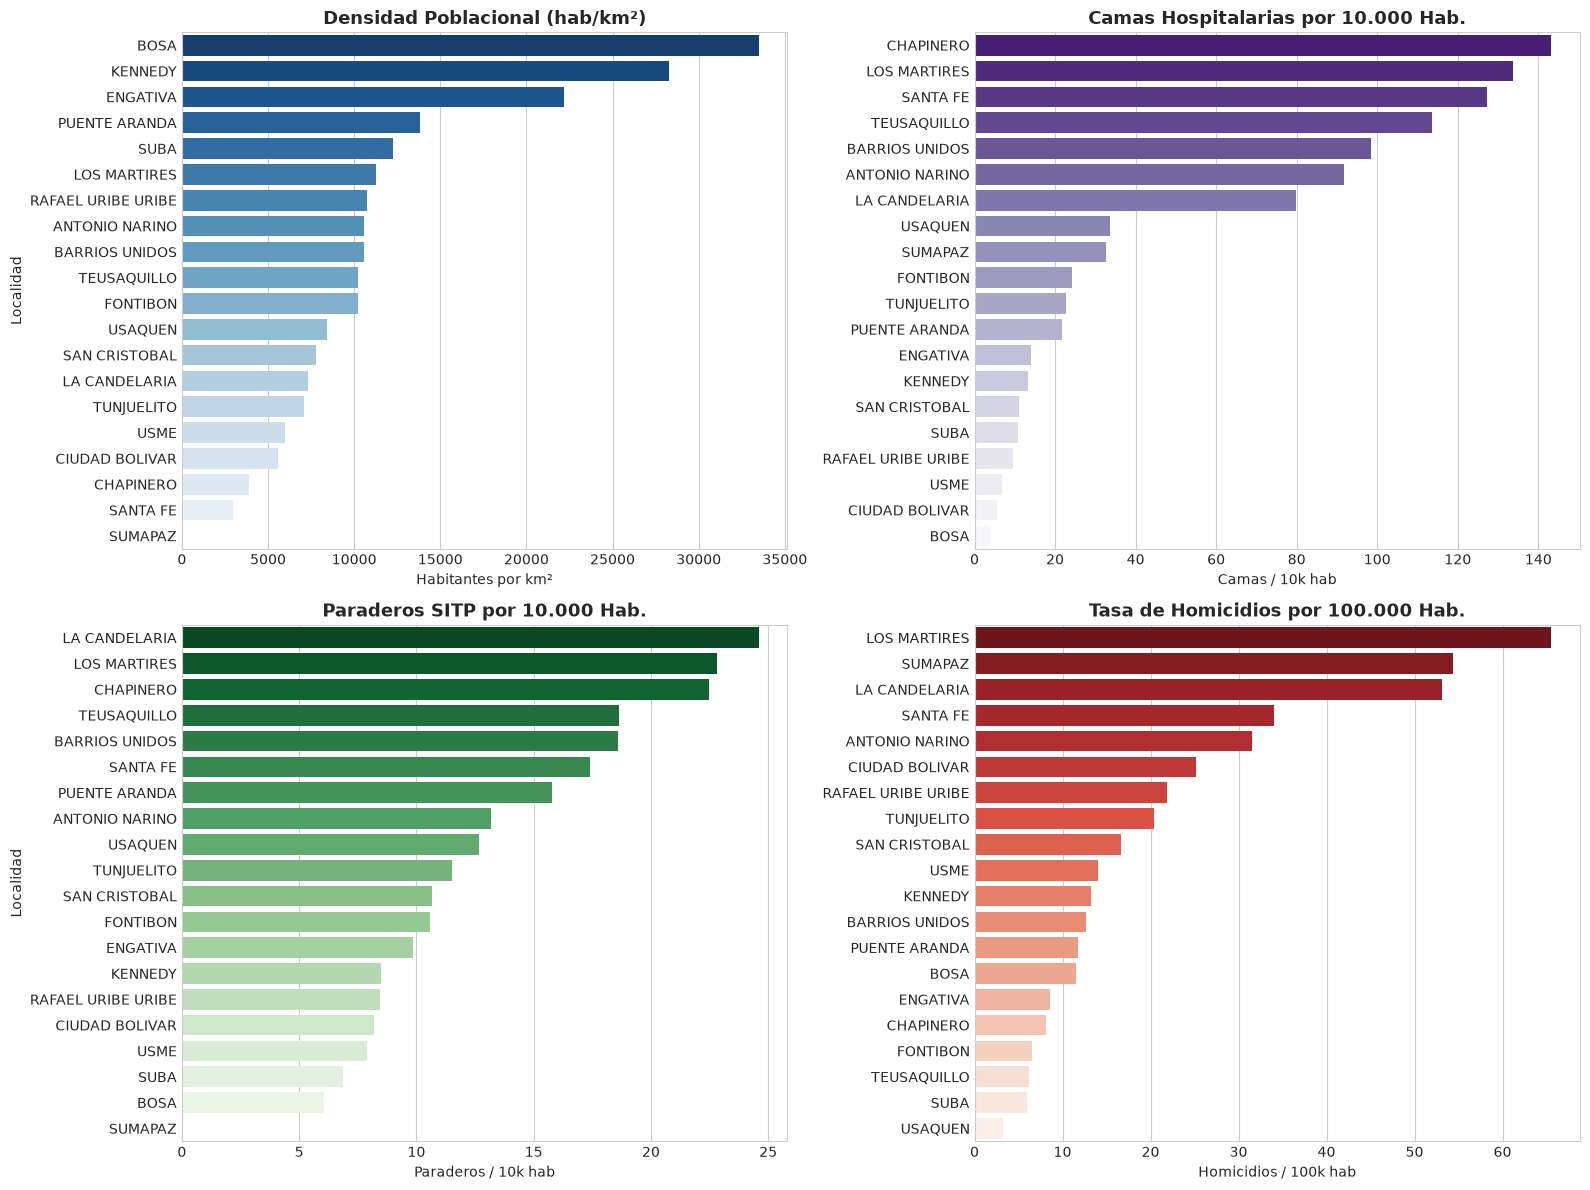

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Densidad Poblacional
df_dens = master_df.sort_values('densidad_poblacional', ascending=False)
sns.barplot(data=df_dens, x='densidad_poblacional', y='nombre_localidad', ax=axes[0, 0], hue='nombre_localidad', palette='Blues_r', legend=False)
axes[0, 0].set_title("Densidad Poblacional (hab/km²)", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Habitantes por km²")
axes[0, 0].set_ylabel("Localidad")

# 2. Camas por 10k Habitantes (Salud)
if 'camas_por_10k_hab_calc' in master_df.columns:
    df_camas = master_df.sort_values('camas_por_10k_hab_calc', ascending=False)
    sns.barplot(data=df_camas, x='camas_por_10k_hab_calc', y='nombre_localidad', ax=axes[0, 1], hue='nombre_localidad', palette='Purples_r', legend=False)
    axes[0, 1].set_title("Camas Hospitalarias por 10.000 Hab.", fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel("Camas / 10k hab")
    axes[0, 1].set_ylabel("")

# 3. Paraderos SITP por 10k Habitantes (Movilidad)
if 'paraderos_por_10k_hab' in master_df.columns:
    df_par = master_df.sort_values('paraderos_por_10k_hab', ascending=False)
    sns.barplot(data=df_par, x='paraderos_por_10k_hab', y='nombre_localidad', ax=axes[1, 0], hue='nombre_localidad', palette='Greens_r', legend=False)
    axes[1, 0].set_title("Paraderos SITP por 10.000 Hab.", fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel("Paraderos / 10k hab")
    axes[1, 0].set_ylabel("Localidad")

# 4. Homicidios por 100k Habitantes (Seguridad)
if 'tasa_homicidios_por_100k_hab_calc' in master_df.columns:
    df_hom = master_df.sort_values('tasa_homicidios_por_100k_hab_calc', ascending=False)
    sns.barplot(data=df_hom, x='tasa_homicidios_por_100k_hab_calc', y='nombre_localidad', ax=axes[1, 1], hue='nombre_localidad', palette='Reds_r', legend=False)
    axes[1, 1].set_title("Tasa de Homicidios por 100.000 Hab.", fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel("Homicidios / 100k hab")
    axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()


## 5. Auditoría de Calidad de Datos (DAMA-BOK & `src.evaluation`)

Se valida la integridad estructural del Tablón Maestro:
- **Completitud**: Porcentaje de valores nulos (debe ser $0.0\%$ tras imputación de negocio).
- **Unicidad**: Códigos de localidad únicos del 1 al 20.
- **Consistencia de Tipos**: Variables numéricas debidamente tipadas como `float64` o `int64`.


In [6]:
total_nulos = q_report["n_null"].sum()
pct_nulos = (total_nulos / (master_df.shape[0] * master_df.shape[1])) * 100

print(f"============================================================")
print(f"REPORTE DE CALIDAD DE DATOS (DAMA-BOK)")
print(f"  * Total de variables evaluadas: {len(q_report)}")
print(f"  * Total de celdas nulas residuales: {total_nulos} ({pct_nulos:.2f}%)")
print(f"  * Códigos duplicados de localidad: {master_df['codigo_localidad'].duplicated().sum()}")
print(f"============================================================")

display(q_report.head(15))


REPORTE DE CALIDAD DE DATOS (DAMA-BOK)
  * Total de variables evaluadas: 67
  * Total de celdas nulas residuales: 0 (0.00%)
  * Códigos duplicados de localidad: 0


,column,dtype,n_null,pct_null,n_unique
0,codigo_localidad,int64,0,0.0,20
1,nombre_localidad,str,0,0.0,20
2,codigo_divipola,str,0,0.0,20
3,area_km2,float64,0,0.0,19
4,poblacion,int64,0,0.0,20
5,total_parques_idrd,int64,0,0.0,14
6,total_paraderos_sitp,int64,0,0.0,20
7,total_estaciones_troncales_tm,int64,0,0.0,13
8,total_camas_hospitalarias,int64,0,0.0,20
9,camas_por_10000_habitantes,float64,0,0.0,20


## 6. Análisis Exploratorio de Correlaciones Intersectoriales

Evaluación de asociaciones entre variables de diferentes dominios (Salud, Educación, Seguridad, Movilidad, Finanzas) para diagnosticar sinergias y brechas estructurales.


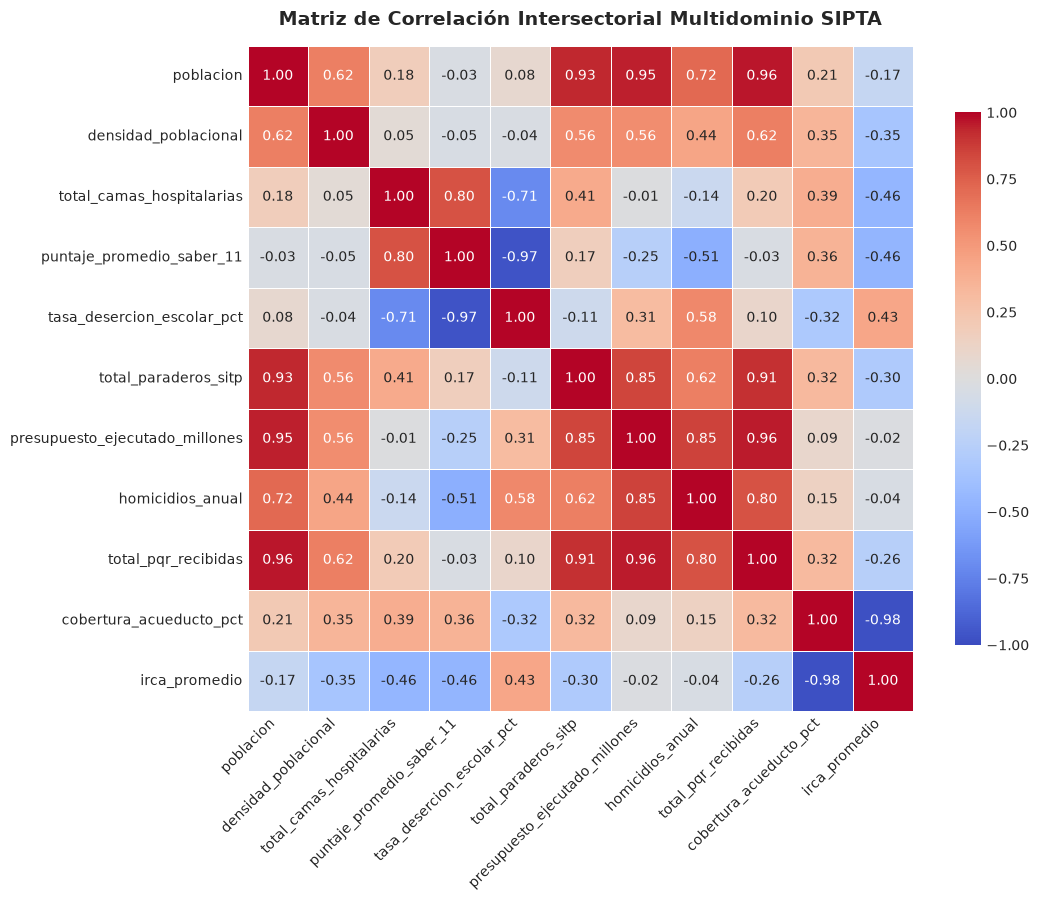

In [7]:
# Selección de variables representativas por dominio
vars_interes = [
    'poblacion',
    'densidad_poblacional',
    'total_camas_hospitalarias',
    'puntaje_promedio_saber_11',
    'tasa_desercion_escolar_pct',
    'total_paraderos_sitp',
    'presupuesto_ejecutado_millones',
    'homicidios_anual',
    'total_pqr_recibidas',
    'cobertura_acueducto_pct',
    'irca_promedio',
]

vars_disponibles = [v for v in vars_interes if v in master_df.columns]
df_corr = master_df[vars_disponibles].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlación Intersectorial Multidominio SIPTA", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Persistencia y Cierre del Entregable de Integración

Se exportan los datasets procesados a disco como interfaz formal hacia la fase de modelado:
- `data/processed/master_localidades.csv`: Tablón maestro con todas las variables integradas.
- `data/processed/master_localidades_features.csv`: Tablón maestro con features de ingeniería derivadas.


In [8]:
out_master = save_master_table(master_df, "master_localidades.csv")
out_features = save_feature_table(master_df, "master_localidades_features.csv")
save_quality_report(q_report, "calidad_master_localidades.csv")

print(f"============================================================")
print(f"ENTREGABLES DE INTEGRACIÓN GENERADOS EXITOSAMENTE")
print(f"  * Tablón Maestro: {out_master}")
print(f"  * Feature Table:  {out_features}")
print(f"  * Filas: {len(master_df)} | Columnas: {master_df.shape[1]}")
print(f"============================================================")


ENTREGABLES DE INTEGRACIÓN GENERADOS EXITOSAMENTE
  * Tablón Maestro: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\processed\master_localidades.csv
  * Feature Table:  C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\processed\master_localidades_features.csv
  * Filas: 20 | Columnas: 67
